# 📈 Yield EDA — Exploratory Data Analysis
**Dataset:** `yield_train.csv` (from processed folder)  
**Task:** Regression — predict `Yield` (kg/ha) from State, District, Crop, Season, Year, Area  
**Notebook:** `03_yield_eda.ipynb`

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 80)

# Dark theme
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#333355',
    'axes.labelcolor'  : '#e0e0f0',
    'text.color'       : '#e0e0f0',
    'xtick.color'      : '#a0a0c0',
    'ytick.color'      : '#a0a0c0',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
})

ACCENT    = '#7c3aed'
ACCENT2   = '#06b6d4'
HIGHLIGHT = '#f59e0b'
GREEN     = '#10b981'
RED       = '#f43f5e'
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
train = pd.read_csv('../data/processed/yield_train.csv')
test  = pd.read_csv('../data/processed/yield_test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
train.head()

Train shape : (271481, 7)
Test  shape : (67871, 7)


,State,District,Crop,Year,Season,Yield,Crop_Category
0,Rajasthan,Chittorgarh,Moong(Green Gram),2018,Kharif,0.50,Pulses
1,Gujarat,Rajkot,Other Kharif pulses,2003,Kharif,0.33,Pulses
2,Andhra Pradesh,Prakasam,Cowpea(Lobia),2014,Rabi,1.28,Pulses
3,Andhra Pradesh,Karimnagar,Cotton(lint),2004,Kharif,1.25,Fiber Crops
4,Karnataka,Bangalorerural,Ragi,1999,Kharif,2.06,Cereals


## 3. Basic Info & Data Types

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271481 entries, 0 to 271480
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State          271481 non-null  object 
 1   District       271481 non-null  object 
 2   Crop           271481 non-null  object 
 3   Year           271481 non-null  int64  
 4   Season         271481 non-null  object 
 5   Yield          271481 non-null  float64
 6   Crop_Category  271481 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 14.5+ MB


In [4]:
train.describe()

,Year,Yield
count,271481.000000,271481.000000
mean,2008.921210,81.313713
std,6.567191,928.569930
min,1997.000000,0.010000
25%,2003.000000,0.570000
50%,2009.000000,1.030000
75%,2015.000000,2.510000
max,2020.000000,43958.330000


## 4. Missing Values

In [5]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
State,0,0.0
District,0,0.0
Crop,0,0.0
Year,0,0.0
Season,0,0.0
Yield,0,0.0
Crop_Category,0,0.0


## 5. Target Variable — Yield Distribution

In [6]:
yield_stats = train['Yield'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
print('Yield Statistics (kg/ha):')
print(yield_stats)
print(f'\nSkewness : {train["Yield"].skew():.4f}')
print(f'Kurtosis : {train["Yield"].kurt():.4f}')

Yield Statistics (kg/ha):
count    271481.000000
mean         81.313713
std         928.569930
min           0.010000
1%            0.100000
5%            0.230000
25%           0.570000
50%           1.030000
75%           2.510000
95%          26.000000
99%         107.020000
max       43958.330000
Name: Yield, dtype: float64

Skewness : 14.6033
Kurtosis : 255.7414


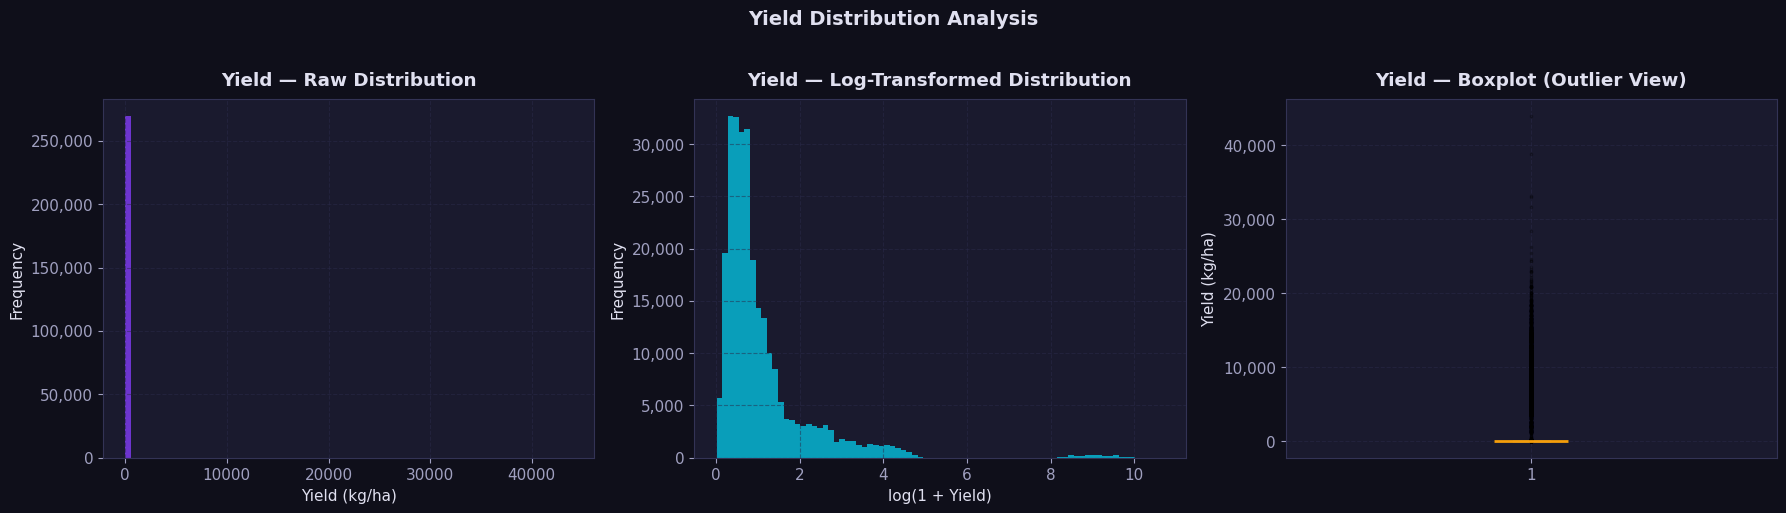

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw histogram
axes[0].hist(train['Yield'], bins=80, color=ACCENT, edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Yield (kg/ha)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Yield — Raw Distribution', fontweight='bold', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True)

# Log-transformed histogram
log_yield = np.log1p(train['Yield'])
axes[1].hist(log_yield, bins=80, color=ACCENT2, edgecolor='none', alpha=0.85)
axes[1].set_xlabel('log(1 + Yield)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Yield — Log-Transformed Distribution', fontweight='bold', pad=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(True)

# Boxplot
axes[2].boxplot(train['Yield'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6),
                medianprops=dict(color=HIGHLIGHT, linewidth=2),
                whiskerprops=dict(color='#a0a0c0'),
                capprops=dict(color='#a0a0c0'),
                flierprops=dict(marker='.', color=RED, alpha=0.3, markersize=3))
axes[2].set_ylabel('Yield (kg/ha)')
axes[2].set_title('Yield — Boxplot (Outlier View)', fontweight='bold', pad=10)
axes[2].grid(True)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Yield Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Outlier Analysis (IQR Method)

In [9]:
Q1  = train['Yield'].quantile(0.25)
Q3  = train['Yield'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = train[(train['Yield'] < lower_fence) | (train['Yield'] > upper_fence)]

print(f'IQR          : {IQR:.2f}')
print(f'Lower fence  : {lower_fence:.2f}')
print(f'Upper fence  : {upper_fence:.2f}')
print(f'Outlier count: {len(outliers):,}  ({len(outliers)/len(train)*100:.2f}% of train)')
print(f'\nTop 10 extreme Yield values:')
train.nlargest(10, 'Yield')[['State', 'Crop_Category', 'Season', 'Yield']]







IQR          : 1.94
Lower fence  : -2.34
Upper fence  : 5.42
Outlier count: 41,072  (15.13% of train)

Top 10 extreme Yield values:


,State,Crop_Category,Season,Yield
76314,Assam,Plantation Crops,Whole Year,43958.33
20667,West Bengal,Plantation Crops,Whole Year,38800.00
138558,Tamil Nadu,Plantation Crops,Whole Year,33133.61
234374,Assam,Plantation Crops,Whole Year,32957.75
242463,Andhra Pradesh,Plantation Crops,Whole Year,31578.95
232234,Assam,Plantation Crops,Whole Year,28334.16
16623,Assam,Plantation Crops,Whole Year,26270.83
270694,Assam,Plantation Crops,Whole Year,25430.46
128853,Tamil Nadu,Plantation Crops,Whole Year,24630.76
76789,Tamil Nadu,Plantation Crops,Whole Year,24414.68


## 7. Yield by Season

In [10]:
season_yield = train.groupby('Season')['Yield'].agg(['median', 'mean', 'std', 'count']).sort_values('median', ascending=False)
season_yield.columns = ['Median Yield', 'Mean Yield', 'Std Yield', 'Count']
print(season_yield.to_string())

            Median Yield  Mean Yield    Std Yield   Count
Season                                                   
Whole Year          4.33  399.765994  2054.531067   53833
Summer              1.60    3.351762     7.176151   17484
Rabi                1.00    2.544982     6.256009   86152
Kharif              0.88    2.426655    18.125007  114012


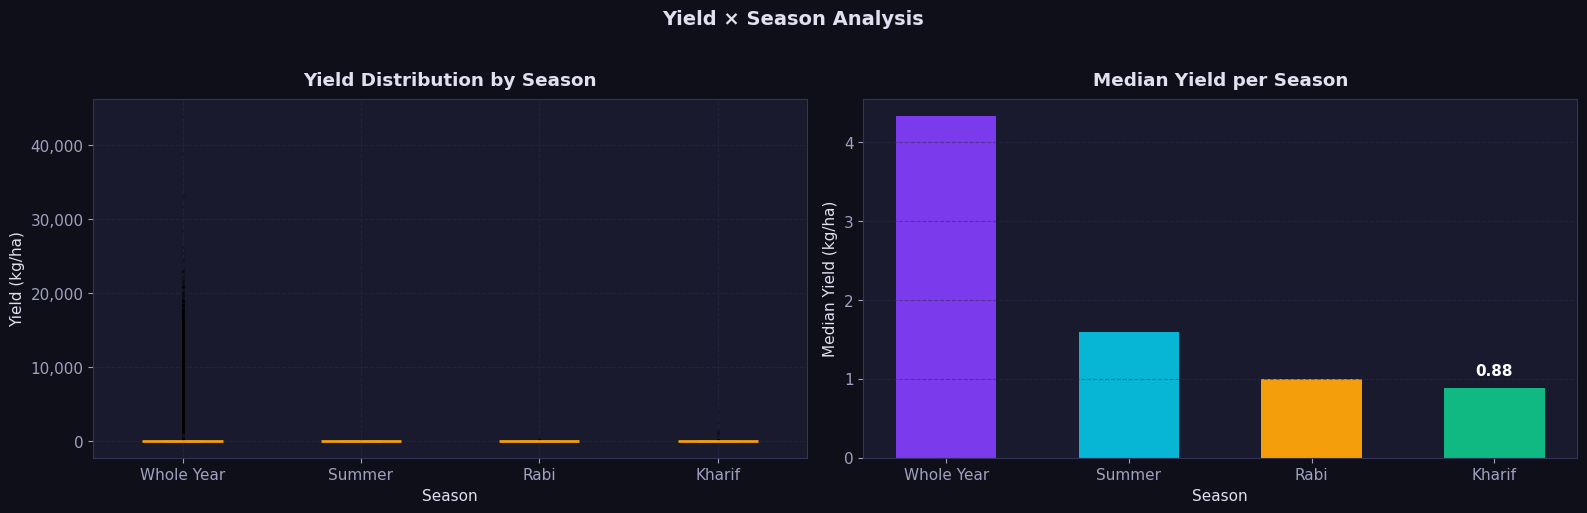

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot by season
seasons_order = train.groupby('Season')['Yield'].median().sort_values(ascending=False).index.tolist()
season_data = [train[train['Season'] == s]['Yield'].values for s in seasons_order]

bp = axes[0].boxplot(season_data, labels=seasons_order, patch_artist=True,
                     medianprops=dict(color=HIGHLIGHT, linewidth=2),
                     whiskerprops=dict(color='#a0a0c0'),
                     capprops=dict(color='#a0a0c0'),
                     flierprops=dict(marker='.', color=RED, alpha=0.2, markersize=2))
season_colors = [ACCENT, ACCENT2, HIGHLIGHT, GREEN]
for patch, color in zip(bp['boxes'], season_colors * 10):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Yield (kg/ha)')
axes[0].set_title('Yield Distribution by Season', fontweight='bold', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True)

# Median bar chart
medians = season_yield['Median Yield'].sort_values(ascending=False)
bar_colors = [ACCENT, ACCENT2, HIGHLIGHT, GREEN]
axes[1].bar(medians.index, medians.values, color=bar_colors[:len(medians)], edgecolor='none', width=0.55)
for i, v in enumerate(medians.values):
    offset = medians.max() * 0.03

axes[1].text(i, v + offset,
             f'{v:.2f}',
             ha='center',
             va='bottom',
             fontsize=11,
             color='white',
             fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Median Yield (kg/ha)')
axes[1].set_title('Median Yield per Season', fontweight='bold', pad=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='y')

fig.suptitle('Yield × Season Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Yield by State (Top 20)

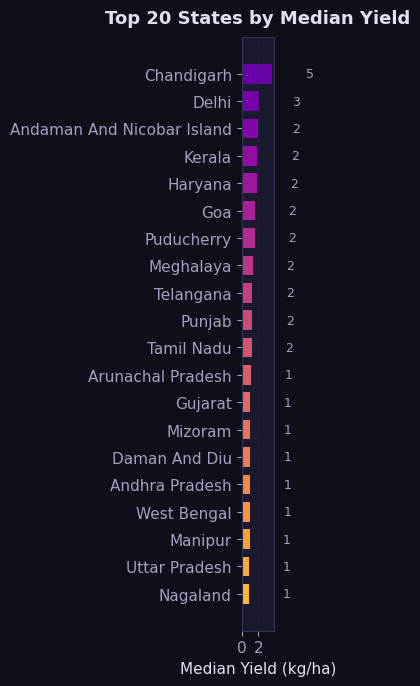

In [12]:
state_yield = train.groupby('State')['Yield'].median().sort_values(ascending=False)
top20_states_yield = state_yield.head(20)

fig, ax = plt.subplots(figsize=(13, 7))
colors_sv = plt.cm.plasma(np.linspace(0.85, 0.2, len(top20_states_yield)))
ax.barh(top20_states_yield.index[::-1], top20_states_yield.values[::-1],
        color=colors_sv, edgecolor='none', height=0.72)
for i, val in enumerate(top20_states_yield.values[::-1]):
    ax.text(val + 5, i, f'{val:,.0f}', va='center', fontsize=9, color='#a0a0c0')

ax.set_xlabel('Median Yield (kg/ha)')
ax.set_title('Top 20 States by Median Yield', fontsize=13, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 9. Top 20 Crops by Yield

In [13]:
crop_yield = train.groupby('Crop_Category')['Yield'].agg(['median', 'count'])
crop_yield.columns = ['Median Yield', 'Count']
# Filter crops with >= 50 records for reliability
reliable_crops = crop_yield[crop_yield['Count'] >= 50].sort_values('Median Yield', ascending=False)

top20_crops_yield = reliable_crops.head(20)
bottom10_crops_yield = reliable_crops.tail(10)

print(f'Crops with >= 50 records: {len(reliable_crops)}')
print('\nTop 20 highest yielding crops:')
top20_crops_yield

Crops with >= 50 records: 9

Top 20 highest yielding crops:


,Median Yield,Count
Crop_Category,,
Cash Crops,42.950,11810
Fruits,23.040,3211
Vegetables,10.750,23414
Plantation Crops,3.005,5274
Fiber Crops,1.960,10599
Cereals,1.540,72391
Spices,1.330,24672
Oilseeds,0.680,51453
Pulses,0.630,68657


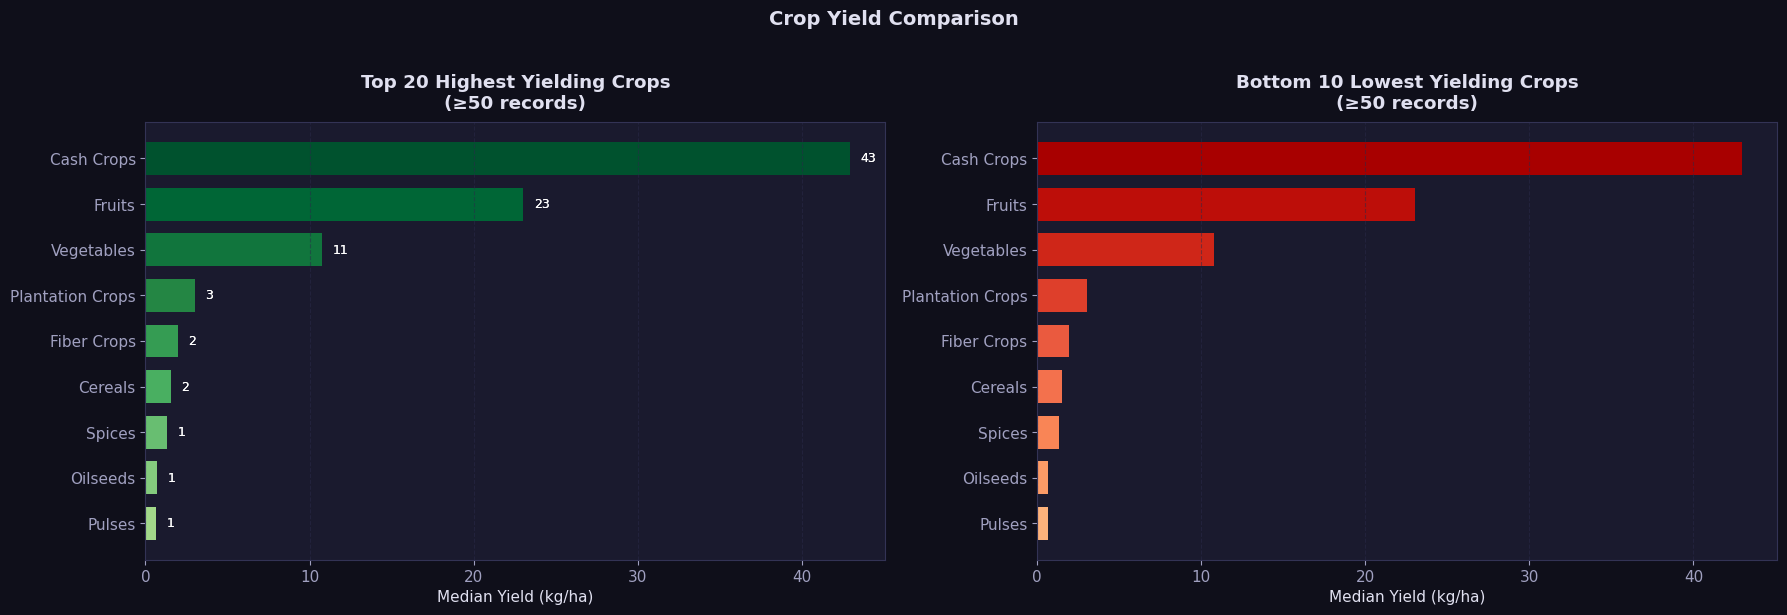

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 high yielda
colors_cy = plt.cm.YlGn(np.linspace(0.4, 0.95, len(top20_crops_yield)))
axes[0].barh(top20_crops_yield.index[::-1], top20_crops_yield['Median Yield'].values[::-1],
             color=colors_cy, edgecolor='none', height=0.72)
offset = top20_crops_yield['Median Yield'].max() * 0.015

for i, val in enumerate(top20_crops_yield['Median Yield'].values[::-1]):
    axes[0].text(
        val + offset,
        i,
        f'{val:,.0f}',
        va='center',
        fontsize=9,
        color='white'
    )
axes[0].set_xlabel('Median Yield (kg/ha)')
axes[0].set_title('Top 20 Highest Yielding Crops\n(≥50 records)', fontweight='bold', pad=10)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='x')

# Bottom 10 low yield
colors_cy2 = plt.cm.OrRd(np.linspace(0.4, 0.9, len(bottom10_crops_yield)))
axes[1].barh(bottom10_crops_yield.index[::-1], bottom10_crops_yield['Median Yield'].values[::-1],
             color=colors_cy2, edgecolor='none', height=0.72)
offset = top20_crops_yield['Median Yield'].max() * 0.015

for i, val in enumerate(top20_crops_yield['Median Yield'].values[::-1]):
    axes[0].text(
        val + offset,
        i,
        f'{val:,.0f}',
        va='center',
        fontsize=9,
        color='white'
    )
axes[1].set_xlabel('Median Yield (kg/ha)')
axes[1].set_title('Bottom 10 Lowest Yielding Crops\n(≥50 records)', fontweight='bold', pad=10)
axes[1].grid(axis='x')

fig.suptitle('Crop Yield Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Yield Trend over Years

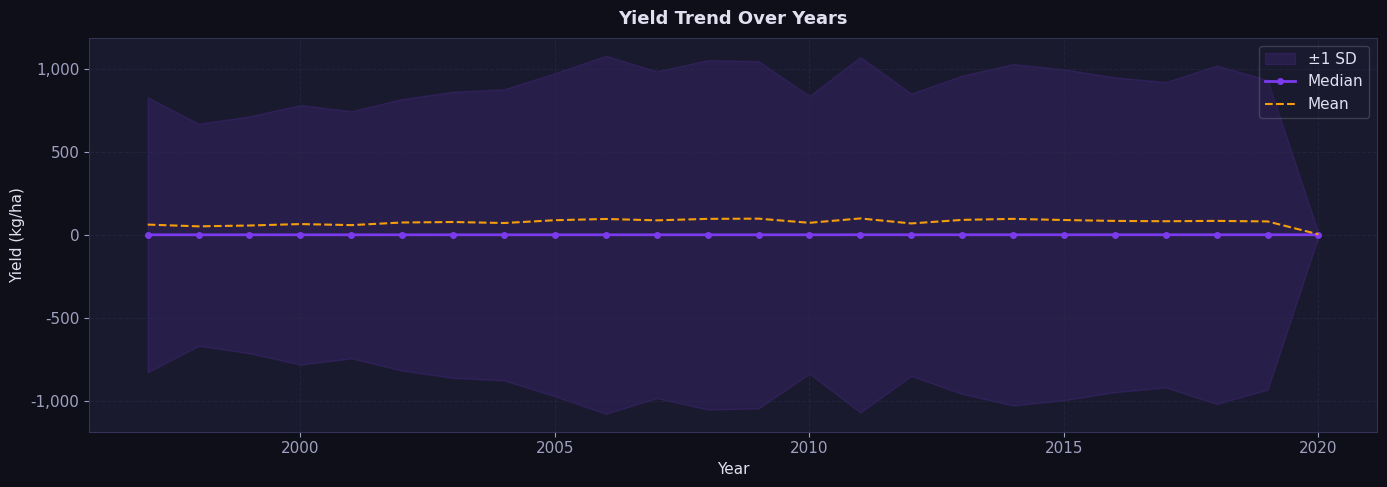

In [15]:
year_yield = train.groupby('Year')['Yield'].agg(['median', 'mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(year_yield['Year'],
                year_yield['median'] - year_yield['std'],
                year_yield['median'] + year_yield['std'],
                alpha=0.15, color=ACCENT, label='±1 SD')
ax.plot(year_yield['Year'], year_yield['median'], color=ACCENT, linewidth=2, marker='o', markersize=4, label='Median')
ax.plot(year_yield['Year'], year_yield['mean'],   color=HIGHLIGHT, linewidth=1.5, linestyle='--', label='Mean')


ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.set_title('Yield Trend Over Years', fontsize=13, fontweight='bold', pad=10)
ax.legend(framealpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
plt.tight_layout()
plt.show()

## 12. Yield Trend by Season over Years

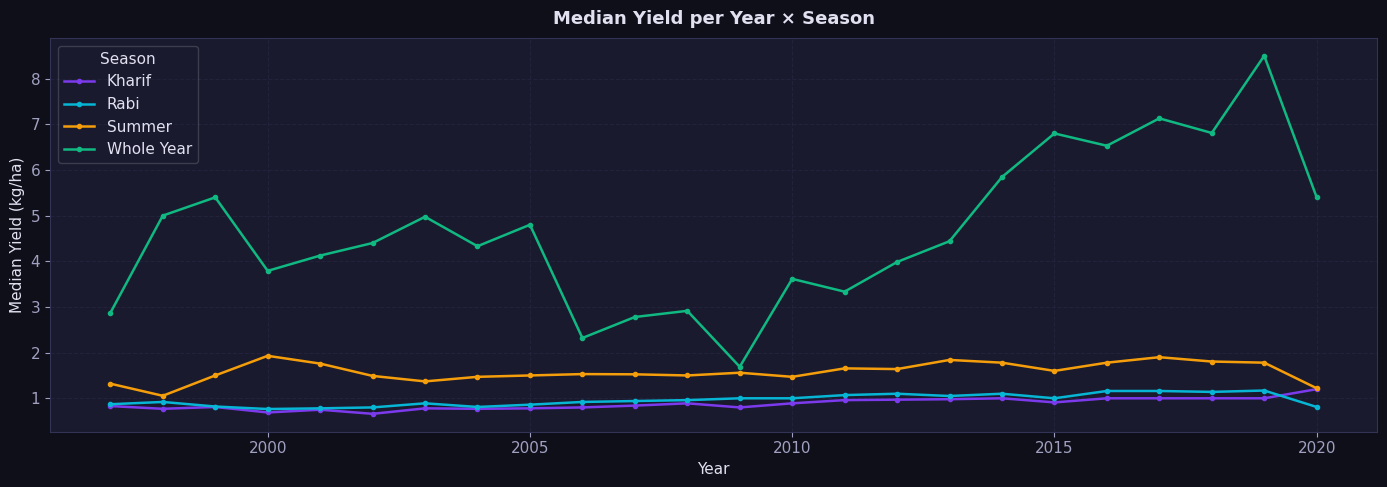

In [16]:
year_season_yield = train.groupby(['Year', 'Season'])['Yield'].median().unstack()

fig, ax = plt.subplots(figsize=(14, 5))
season_colors_map = {'Kharif': ACCENT, 'Rabi': ACCENT2, 'Summer': HIGHLIGHT, 'Whole Year': GREEN}

for season in year_season_yield.columns:
    color = season_colors_map.get(season, '#cccccc')
    ax.plot(year_season_yield.index, year_season_yield[season],
            marker='o', markersize=3, linewidth=1.8, color=color, label=season)

ax.set_xlabel('Year')
ax.set_ylabel('Median Yield (kg/ha)')
ax.set_title('Median Yield per Year × Season', fontsize=13, fontweight='bold', pad=10)
ax.legend(title='Season', framealpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
plt.tight_layout()
plt.show()

## 13. Correlation Heatmap (Numerical Features)

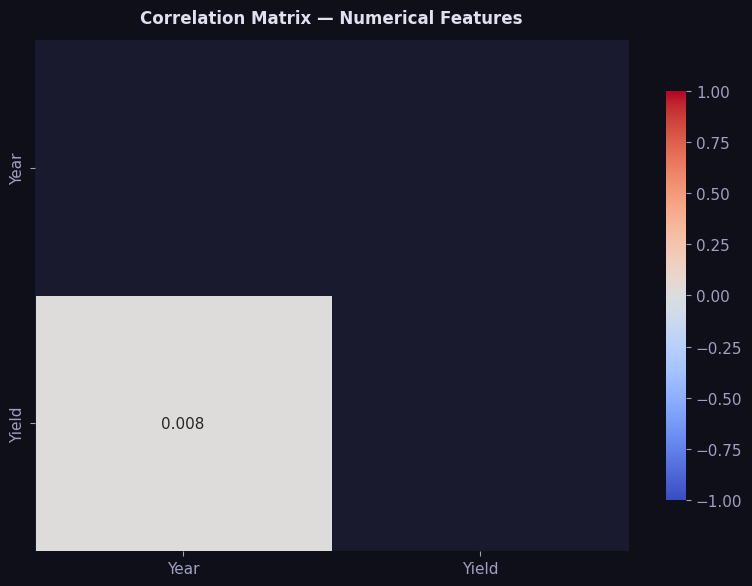

In [17]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, linecolor='#1a1a2e',
            cbar_kws={'shrink': 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=12, pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Yield Distribution — Top 15 Crops (Violin)

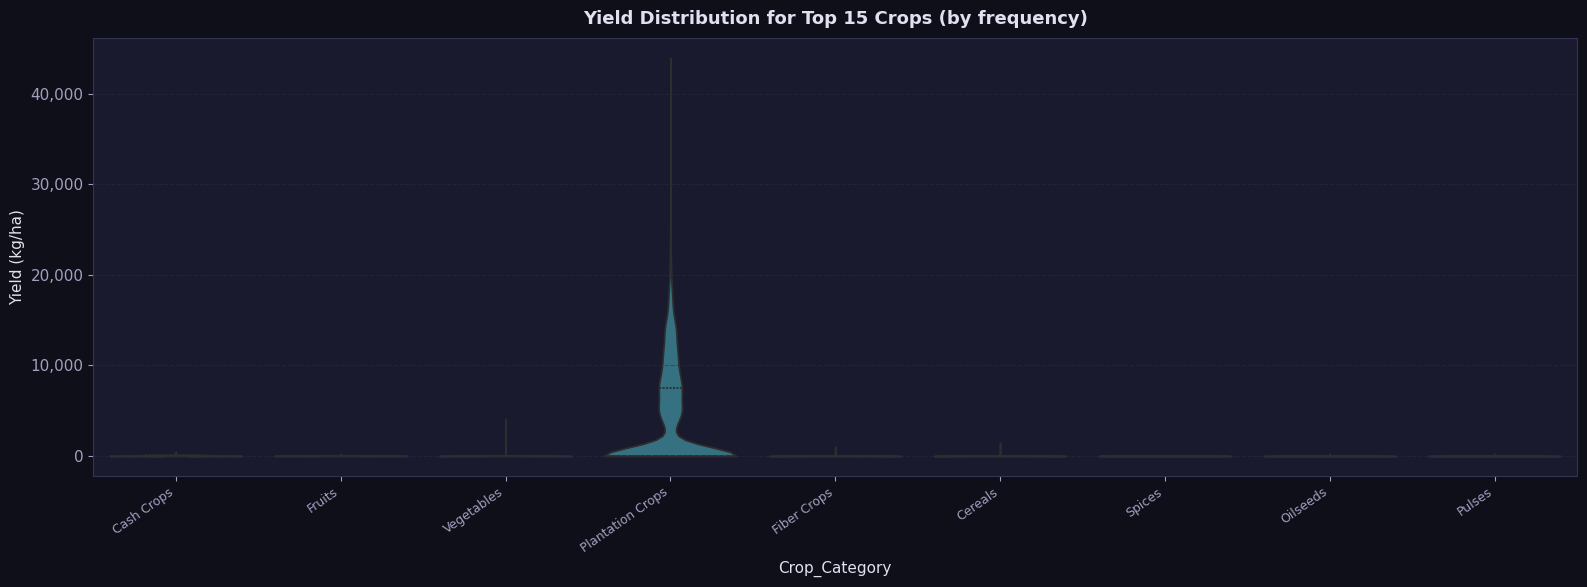

In [18]:
top15_by_count = train['Crop_Category'].value_counts().head(15).index.tolist()
subset_top15 = train[train['Crop_Category'].isin(top15_by_count)]

# Order by median yield
order = subset_top15.groupby('Crop_Category')['Yield'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(16, 6))
sns.violinplot(data=subset_top15, x='Crop_Category', y='Yield', order=order,
               palette='viridis', inner='quartile', ax=ax, cut=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_xlabel('Crop_Category')
ax.set_ylabel('Yield (kg/ha)')
ax.set_title('Yield Distribution for Top 15 Crops (by frequency)', fontsize=13, fontweight='bold', pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 15. State × Season Median Yield Heatmap

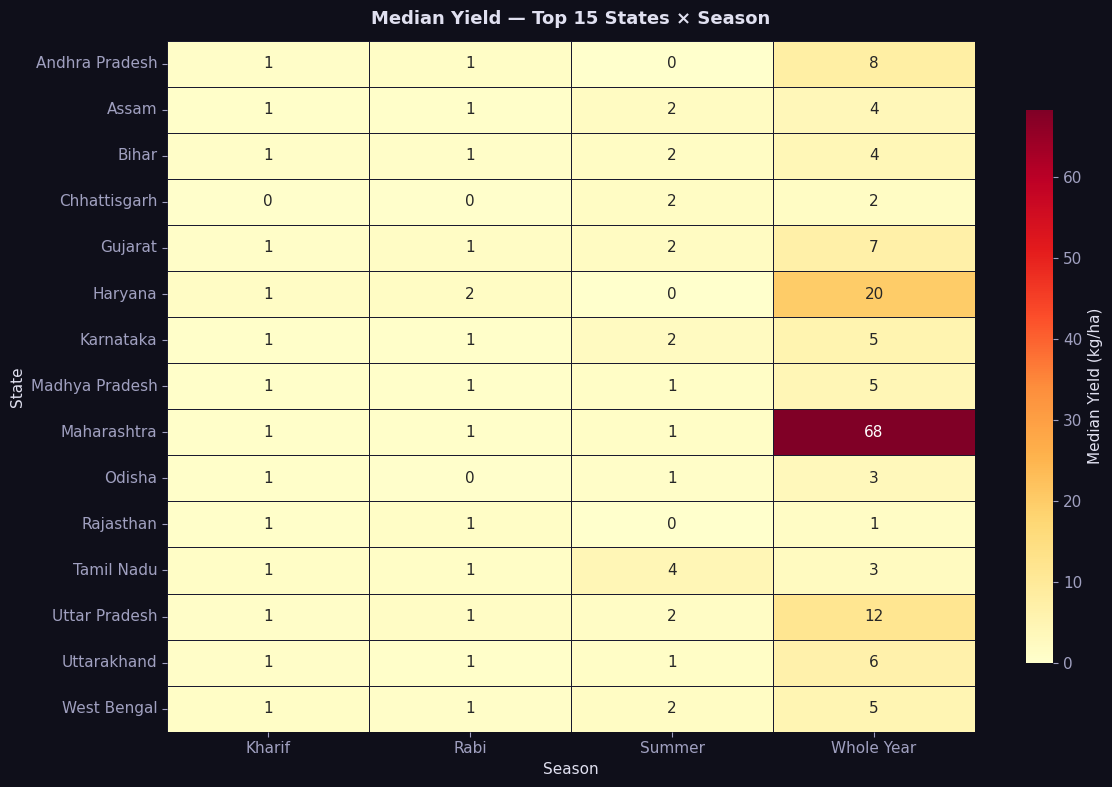

In [19]:
top15_states = train['State'].value_counts().head(15).index.tolist()
subset_states = train[train['State'].isin(top15_states)]

pivot_ss = subset_states.groupby(['State', 'Season'])['Yield'].median().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_ss, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#1a1a2e',
            cbar_kws={'label': 'Median Yield (kg/ha)', 'shrink': 0.8},
            ax=ax)
ax.set_title('Median Yield — Top 15 States × Season', fontsize=13, pad=12, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

## 17. EDA Summary

In [20]:
print('=' * 55)
print('         YIELD EDA — KEY FINDINGS')
print('=' * 55)
print(f'  Train records         : {len(train):,}')
print(f'  Test  records         : {len(test):,}')
print(f'  Columns               : {list(train.columns)}')
print(f'  Unique Crops Category : {train["Crop_Category"].nunique()}')
print(f'  Unique States         : {train["State"].nunique()}')
print(f'  Unique Seasons        : {train["Season"].nunique()}')
print(f'  Year range            : {train["Year"].min()} – {train["Year"].max()}')
print(f'  Missing values        : {train.isnull().sum().sum()}')
print()
print(f'  Yield (kg/ha):')
print(f'    Min     : {train["Yield"].min():,.4f}')
print(f'    Median  : {train["Yield"].median():,.2f}')
print(f'    Mean    : {train["Yield"].mean():,.2f}')
print(f'    Max     : {train["Yield"].max():,.2f}')
print(f'    Skew    : {train["Yield"].skew():.4f}  (right-skewed — log transform recommended)')
print(f'  IQR outliers          : {len(outliers):,} ({len(outliers)/len(train)*100:.1f}%)')
print(f'  Highest yield state   : {state_yield.idxmax()}')
print(f'  Best season (median)  : {train.groupby("Season")["Yield"].median().idxmax()}')
print('=' * 55)

         YIELD EDA — KEY FINDINGS
  Train records         : 271,481
  Test  records         : 67,871
  Columns               : ['State', 'District', 'Crop', 'Year', 'Season', 'Yield', 'Crop_Category']
  Unique Crops Category : 9
  Unique States         : 37
  Unique Seasons        : 4
  Year range            : 1997 – 2020
  Missing values        : 0

  Yield (kg/ha):
    Min     : 0.0100
    Median  : 1.03
    Mean    : 81.31
    Max     : 43,958.33
    Skew    : 14.6033  (right-skewed — log transform recommended)
  IQR outliers          : 41,072 (15.1%)
  Highest yield state   : Chandigarh
  Best season (median)  : Whole Year
